In [59]:

print("\n Importing libraries...\n")
import os
import sys
import time
from torchdiffeq import odeint as odeint

sys.path.append("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors
from mpl_toolkits import mplot3d
from numpy import linalg as la
from scipy import stats
from scipy import spatial as sp
from scipy import integrate as integ
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from ipywidgets import interact, IntSlider
import types
import lyapynov as lya 

import multiprocessing as mp

import models.DynamicalSystems as ds

import models.Neural_ODEs_v2 as nodes


 Importing libraries...



In [60]:
torch.set_default_dtype(torch.float32)
torch.set_default_device('cpu')

In [ ]:
interval_lengths = torch.arange(1, 5, 1, dtype=torch.float32)

In [62]:
torch.save(torch.tensor(8), "lle_node_num_saved.pt")

In [ ]:
init_tensor = torch.load("init_tensor_all_intervals_sn.pt").cpu()

In [ ]:
data = [torch.load(f"lle_node_{int(i)}_interval_sn.pt") for i in interval_lengths]

In [ ]:
data_frozen = torch.load(f"lle_node_frozen_sn.pt")

In [73]:
data_frozen.shape

torch.Size([100, 1])

In [65]:
torch_data = torch.stack(data).cpu()

In [66]:
torch_data.shape

torch.Size([10, 100, 1])

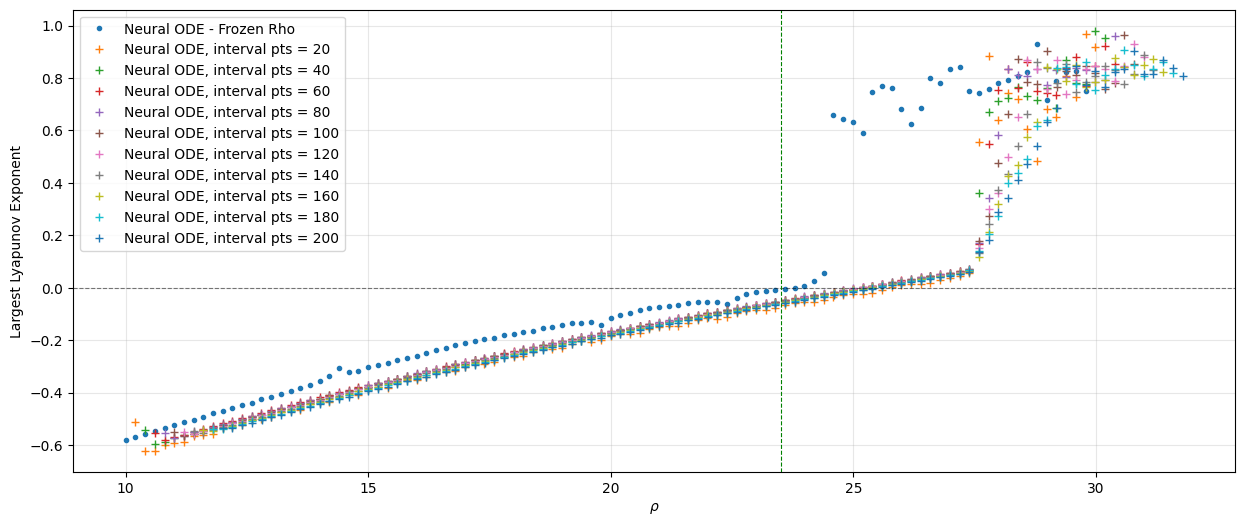

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)

# Saddlenode plot

axes.plot(init_tensor[:, 1].detach(), data_frozen.cpu().detach(), linestyle='', marker='o', markersize = 3, label='Neural ODE - Frozen Parameter')

for i in range(len(interval_lengths)-3):
    axes.plot(init_tensor[:, 1].detach()+interval_lengths[i+3]*0.01, torch_data[i, :].detach().numpy(), linestyle='', marker='+', label='Neural ODE, interval = ' + str(interval_lengths[i+3].item()))


axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)


axes.set_ylabel('Largest Lyapunov Exponent')
axes.set_xlabel(r'$a$ (bifurcation parameter)')

axes.grid(True, alpha=0.3)
axes.legend()
plt.show()

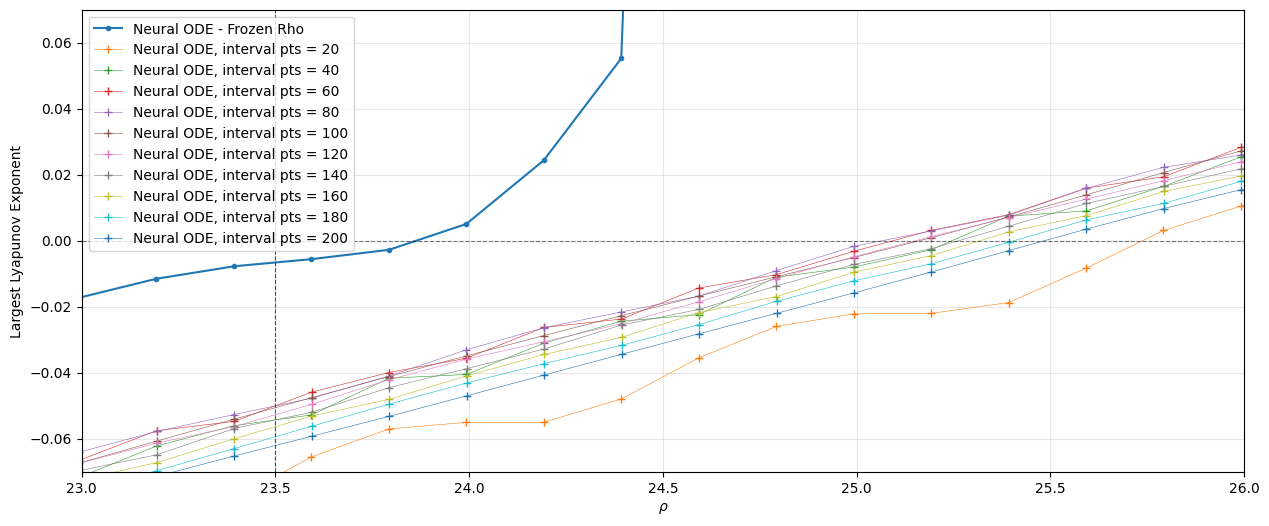

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharey=True)
axes.plot(init_tensor[:, 1].detach(), data_frozen.cpu().detach(), linestyle='-', marker='o', markersize = 3, label='Neural ODE - Frozen Parameter')

# Saddlenode plot
for i in range(len(interval_lengths)-3):
    axes.plot(init_tensor[:, 1].detach()+interval_lengths[i+3]*0.01, torch_data[i, :].detach().numpy(), linestyle='-', marker='+', linewidth=0.4, label='Neural ODE, interval = ' + str(interval_lengths[i+3].item()))


axes.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)


axes.set_ylabel('Largest Lyapunov Exponent')
axes.set_xlabel(r'$a$ (bifurcation parameter)')
axes.set_xlim(-0.5, 0)
axes.grid(True, alpha=0.3)
axes.legend()
plt.show()

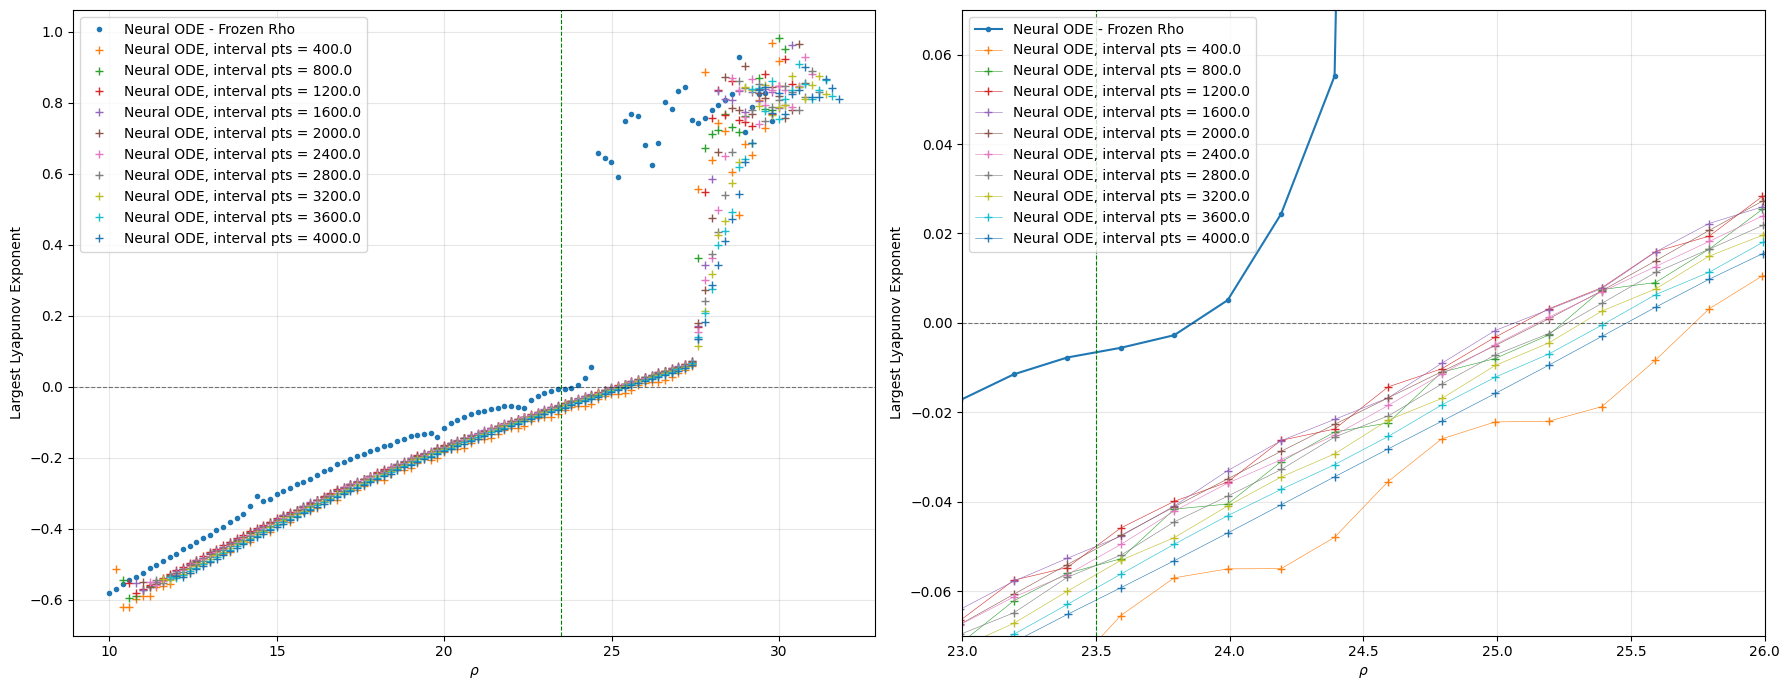

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Left plot - Full view
axes[0].plot(init_tensor[:, 1].detach(), data_frozen.cpu().detach(), linestyle='', marker='o', markersize = 3, label='Neural ODE - Frozen Parameter')

for i in range(len(interval_lengths)-3):
    axes[0].plot(init_tensor[:, 1].detach()+interval_lengths[i+3]*0.01, torch_data[i, :].detach().numpy(), linestyle='', marker='+', label='Neural ODE, interval = ' + str(interval_lengths[i+3].item()))

axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$a$ (bifurcation parameter)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right plot - Zoomed view
axes[1].plot(init_tensor[:, 1].detach(), data_frozen.cpu().detach(), linestyle='-', marker='o', markersize = 3, label='Neural ODE - Frozen Parameter')

for i in range(len(interval_lengths)-3):
    axes[1].plot(init_tensor[:, 1].detach()+interval_lengths[i+3]*0.01, torch_data[i, :].detach().numpy(), linestyle='-', marker='+', linewidth=0.4, label='Neural ODE, interval = ' + str(interval_lengths[i+3].item()))

axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$a$ (bifurcation parameter)')
axes[1].set_xlim(-0.5, 0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()